# Applied Statistics Assessment Problems
by Gustavo Fernandes
***

## Problem 1: Extending the Lady Tasting Tea

Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

### Step 1: Importing the necessary libraries

In [37]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import itertools

***

### Step 2: Setting up the experiment parameters

In [38]:
#Number of cup of tea in total
total_cups = 12
#Number of tea-first cups
tea_first_cups = 8
#Number of milk-first cups
milk_first_cups = 4

***

### Step 3: Calculating the total number of arrangements

In [39]:
ways_to_arrange = math.comb(total_cups, tea_first_cups)
print(f"Total number of ways to arrange the cups: {ways_to_arrange}")

Total number of ways to arrange the cups: 495


 Considering that we will select 8 cups out of 12, we can calculate the total number of arrangements

In [40]:
ways_ordered = 12 * 11 * 10 * 9 * 8 * 7 * 6 * 5
num_shuffles = 8 * 7 * 6 * 5 * 4 * 3 * 2 * 1
num_combs = ways_ordered // num_shuffles
print(f'total ways ordered: {ways_ordered}, no shuffles: {num_shuffles}, no combinations: {num_combs}')

total ways ordered: 19958400, no shuffles: 40320, no combinations: 495


In [41]:
# Defining n and k
n = 12
k = 8
# Where n is the total number of cups and k is the number of tea-first cups
# Calculating the factorials
n_factorial = math.factorial(n)
k_factorial = math.factorial(k)
n_k_factorial = math.factorial(n - k)
print(f"n!: {n_factorial}, k!: {k_factorial}, (n-k)!: {n_k_factorial}")

n!: 479001600, k!: 40320, (n-k)!: 24


In [42]:
# No of ways of selecting k objects from n without replacement and without order.
math.factorial(n) // (math.factorial(k) * math.factorial(n - k))


495

***

### Step 4: Ordering and Labeling Result

In [43]:
# Generating labels for the cups
labels = list(range(total_cups))
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [44]:
# Generating all combinations of tea-first cups
combs = list(itertools.combinations(labels, tea_first_cups))
combs

[(0, 1, 2, 3, 4, 5, 6, 7),
 (0, 1, 2, 3, 4, 5, 6, 8),
 (0, 1, 2, 3, 4, 5, 6, 9),
 (0, 1, 2, 3, 4, 5, 6, 10),
 (0, 1, 2, 3, 4, 5, 6, 11),
 (0, 1, 2, 3, 4, 5, 7, 8),
 (0, 1, 2, 3, 4, 5, 7, 9),
 (0, 1, 2, 3, 4, 5, 7, 10),
 (0, 1, 2, 3, 4, 5, 7, 11),
 (0, 1, 2, 3, 4, 5, 8, 9),
 (0, 1, 2, 3, 4, 5, 8, 10),
 (0, 1, 2, 3, 4, 5, 8, 11),
 (0, 1, 2, 3, 4, 5, 9, 10),
 (0, 1, 2, 3, 4, 5, 9, 11),
 (0, 1, 2, 3, 4, 5, 10, 11),
 (0, 1, 2, 3, 4, 6, 7, 8),
 (0, 1, 2, 3, 4, 6, 7, 9),
 (0, 1, 2, 3, 4, 6, 7, 10),
 (0, 1, 2, 3, 4, 6, 7, 11),
 (0, 1, 2, 3, 4, 6, 8, 9),
 (0, 1, 2, 3, 4, 6, 8, 10),
 (0, 1, 2, 3, 4, 6, 8, 11),
 (0, 1, 2, 3, 4, 6, 9, 10),
 (0, 1, 2, 3, 4, 6, 9, 11),
 (0, 1, 2, 3, 4, 6, 10, 11),
 (0, 1, 2, 3, 4, 7, 8, 9),
 (0, 1, 2, 3, 4, 7, 8, 10),
 (0, 1, 2, 3, 4, 7, 8, 11),
 (0, 1, 2, 3, 4, 7, 9, 10),
 (0, 1, 2, 3, 4, 7, 9, 11),
 (0, 1, 2, 3, 4, 7, 10, 11),
 (0, 1, 2, 3, 4, 8, 9, 10),
 (0, 1, 2, 3, 4, 8, 9, 11),
 (0, 1, 2, 3, 4, 8, 10, 11),
 (0, 1, 2, 3, 4, 9, 10, 11),
 (0, 1, 2, 3, 5, 6, 7, 8)

In [45]:
# Check the number of combinations
len(combs)

495

In [46]:
# Sampling random labels for tea-first
labels_tea = random.sample(labels, 8)
# Creating milk-first labels
labels_milk = list(label for label in labels if label not in labels_tea)
#Sortinig the labels
labels_tea.sort()
labels_milk.sort()
print(f'Tea-first cup labels: {labels_tea}, Milk-first cup labels: {labels_milk}')

Tea-first cup labels: [0, 1, 3, 4, 5, 6, 7, 11], Milk-first cup labels: [2, 8, 9, 10]


In [47]:
# Converting to sets for easier comparison
set(labels_tea)
set(labels_milk)
print(set(labels_tea))
print(set(labels_milk))

{0, 1, 3, 4, 5, 6, 7, 11}
{8, 9, 2, 10}


In [48]:
# Calculate the overlap between each element of combs and labels_milk

num_overlap = []

for i in combs:
    s1 = set(i)
    s2 = set(labels_milk)
    overlap = s1.intersection(s2)
    num_overlap.append(len(overlap))
    print(f'Combination: {i}, Overlap with milk-first labels: {overlap}, length of overlap: {len(overlap)}')
print(f'Total Overlap: {num_overlap}')

counts = np.unique(num_overlap, return_counts=True)
print(f'Total Unique overlap count: {counts}')

Combination: (0, 1, 2, 3, 4, 5, 6, 7), Overlap with milk-first labels: {2}, length of overlap: 1
Combination: (0, 1, 2, 3, 4, 5, 6, 8), Overlap with milk-first labels: {8, 2}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 9), Overlap with milk-first labels: {9, 2}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 10), Overlap with milk-first labels: {2, 10}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 11), Overlap with milk-first labels: {2}, length of overlap: 1
Combination: (0, 1, 2, 3, 4, 5, 7, 8), Overlap with milk-first labels: {8, 2}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 7, 9), Overlap with milk-first labels: {9, 2}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 7, 10), Overlap with milk-first labels: {2, 10}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 7, 11), Overlap with milk-first labels: {2}, length of overlap: 1
Combination: (0, 1, 2, 3, 4, 5, 8, 9), Overlap with milk-first labels: {8, 9, 2}, length of overlap: 3


<BarContainer object of 5 artists>

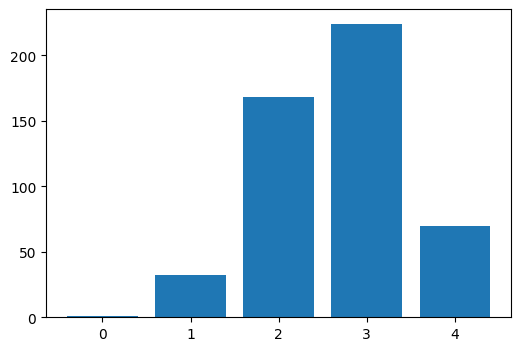

In [49]:
# Create a figure.
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1])

In [50]:
# The probability that she (randomly) selects the eight correct cups.

# Count perfect guesses (0 overlap means no mistakes - all correct)
perfect_guesses = num_overlap.count(0)
total_combinations = len(num_overlap)

print(f"Perfect guesses (0 mistakes): {perfect_guesses}")
print(f"Total possible combinations: {total_combinations}")

# Calculate probability
probability_perfect = perfect_guesses / total_combinations
print(f"Probability of perfect guess: {probability_perfect}")
print(f"As a fraction: {perfect_guesses}/{total_combinations}")
print(f"As a percentage: {probability_perfect * 100:.6f}%")
print(f"This is 1 in {total_combinations/perfect_guesses:.0f} chance")

Perfect guesses (0 mistakes): 1
Total possible combinations: 495
Probability of perfect guess: 0.00202020202020202
As a fraction: 1/495
As a percentage: 0.202020%
This is 1 in 495 chance


***
## Problem 2: Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

In [51]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm

In [52]:
# Generate 100,000 samples of 10 coin flips each
flips = []
for i in range(100000):
    # Each iteration generates 10 coin flips (1=heads, 0=tails)
    ten_flips = np.random.binomial(1, 0.5, 10)
    flips.append(ten_flips)
print(f"Example first sample: {flips[0]}")
print(f"Generated {len(flips)} samples of 10 coin flips each")

Example first sample: [1 0 1 1 1 1 0 1 0 0]
Generated 100000 samples of 10 coin flips each


In [53]:
# Convert to numpy array for easier manipulation
flips_array = np.array(flips)

# Count total heads and tails across all flips
#total_heads = np.sum(flips_array)
#total_tails = flips_array.size - total_heads

#or
unique, counts = np.unique(flips_array, return_counts=True)
count_dict = dict(zip(unique, counts))
total_heads = count_dict.get(1, 0)
total_tails = count_dict.get(0, 0)

heads_per_sample = np.sum(flips_array, axis=1)

# Count heads per sample (this might be more useful)
heads_per_sample = np.sum(flips_array, axis=1)
print(f"Total heads: {total_heads}")

print(f"Total tails: {total_tails}")
print(f"Total flips: {total_heads + total_tails}")

Total heads: 499493
Total tails: 500507
Total flips: 1000000


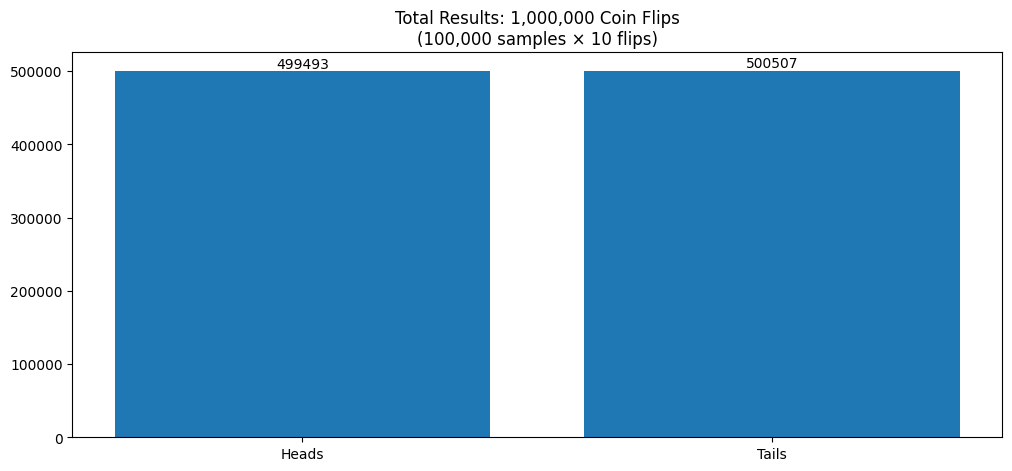

In [54]:
# Plot total heads vs tails
fig, ax1 = plt.subplots(1, figsize=(12, 5))

# Total heads vs tails
ax1.bar(['Heads', 'Tails'], [total_heads, total_tails])
ax1.bar_label(ax1.containers[0])

ax1.set_title('Total Results: 1,000,000 Coin Flips\n(100,000 samples × 10 flips)')
plt.show()

***

In [55]:
# Count the number of times each value occurs.
uniques, counts = np.unique(heads_per_sample, return_counts=True)
#show
unique, counts

(array([0, 1], dtype=int32),
 array([  107,   988,  4437, 11775, 20604, 24407, 20451, 11805,  4411,
          924,    91]))

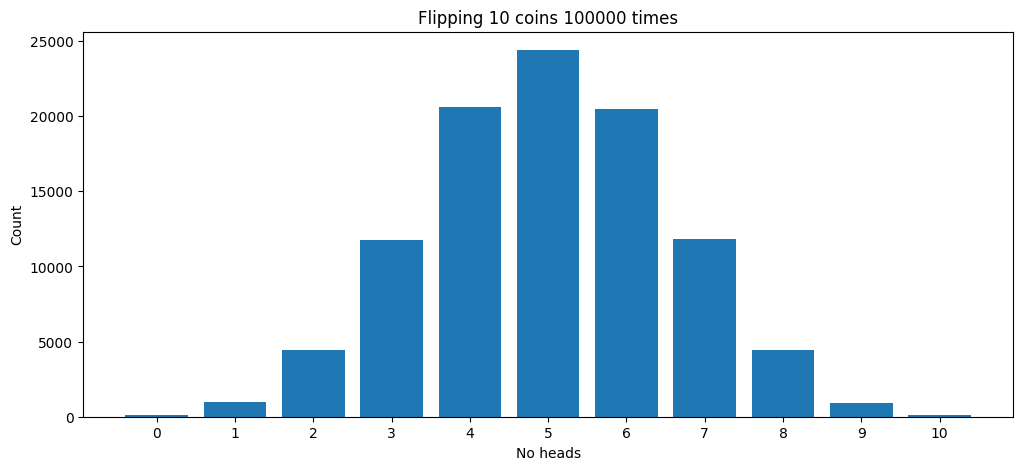

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))

# Create a bar chart.
ax.bar(uniques, counts)

# Set x ticks.
ax.set_xticks(uniques)

# Add title.
ax.set_title(f'Flipping {10} coins {len(flips)} times')

# Add axis label.
ax.set_xlabel('No heads')
ax.set_ylabel('Count');

In [57]:
stats.shapiro(flips)

C:\Users\gusgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1000000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.6366198296752151), pvalue=np.float64(3.2220976486841365e-199))

***

### Analysis and Explanation

### Differences Observed:

1. **Sample SD (ddof=1) vs Population SD (ddof=0)**:
   - Sample SD values are consistently **higher** than Population SD values
   - This is because ddof=1 uses (n-1) in the denominator, making the result larger
   - The sample SD corrects for bias when estimating population variance from a sample

2. **Distribution Characteristics**:
   - Both distributions have similar shapes but different centers
   - Sample SD distribution is shifted to the right compared to Population SD
   - The ratio between them is approximately √(10/9) ≈ 1.054

3. **Bias Correction**:
   - Population SD (ddof=0) gives a **biased estimate** of the true population standard deviation
   - Sample SD (ddof=1) gives an **unbiased estimate** of the population standard deviation
   - This is why we typically use ddof=1 for sample statistics

### Expected Changes with Larger Sample Sizes:

1. **Convergence**: As sample size increases, the difference between ddof=0 and ddof=1 becomes smaller
2. **Reduced Bias**: The bias in ddof=0 decreases as n increases (bias factor = √((n-1)/n) → 1)
3. **Lower Variance**: Both estimators become more precise (less variability) with larger samples
4. **Practical Impact**: For very large samples (n>100), the choice between ddof=0 and ddof=1 becomes negligible

**Key Takeaway**: Always use ddof=1 for sample statistics unless you specifically need the population formula!

***
## Problem 3: t-Tests
A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference 
d=0, 0.1,0.2,…,1.0, repeat the following simulation 1,000 times:

1. Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean d and standard deviation 1.
2. Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05.
3. Record the proportion of times the null hypothesis is not rejected.

Plot this proportion against d, and explain how the type II error rate changes as the difference in means increases.

### Step 1: Import and setup

In [58]:
# import stuff from t-tests file
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# setup simulation
num_simulations = 1000
sample_size = 100
alpha = 0.05

# mean differences to test
mean_differences = np.arange(0, 1.1, 0.1)

### Step 2: Run simulations

In [ ]:
# store the type II errors
type_ii_errors = []

# loop thru each mean difference
for d in mean_differences:
    type_ii_count = 0
    
    # do 1000 simulations
    for i in range(num_simulations):
        # get sample 1 with mean 0
        sample1 = np.random.normal(0, 1, sample_size)
        
        # get sample 2 with mean d
        sample2 = np.random.normal(d, 1, sample_size)
        
        # do t-test
        t_stat, p_value = stats.ttest_ind(sample1, sample2)
        
        # if p-value >= alpha we dont reject null (type II error)
        if p_value >= alpha:
            type_ii_count += 1
    
    # calculate proportion
    type_ii_rate = type_ii_count / num_simulations
    type_ii_errors.append(type_ii_rate)
    
print("done!")

### Step 3: Make plot

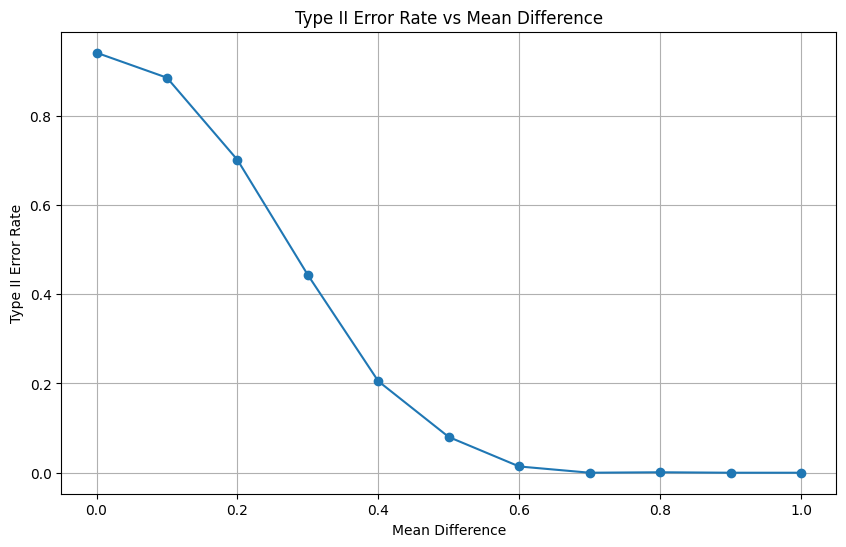

In [ ]:
# plot it
plt.figure(figsize=(10, 6))
plt.plot(mean_differences, type_ii_errors, marker='o')
plt.xlabel('Mean Difference')
plt.ylabel('Type II Error Rate')
plt.title('Type II Error Rate vs Mean Difference')
plt.grid(True)
plt.show()

### Results

The plot shows that when mean difference is 0, the type II error is high (around 95%). This is becuase when theres no actual difference, we correctly fail to reject the null most of the time.

As the mean difference gets bigger, the type II error goes down. This happens because its easier to detect bigger differences betwen the samples.

When the difference is large (like 1.0), the type II error is almost 0, meaning we almost always reject the null when there really is a difference.

***
## Problem 4: ANOVA

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

Perform a one-way ANOVA to test whether all three means are equal.
Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
Compare the conclusions.
Write a short note on why ANOVA is preferred over running several t-tests.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
np.random.seed(12)

np.random.normal(loc=0, scale=1, size=30)

In [ ]:
n=30
s1 = np.random.normal(loc=0, scale=1, size=n)
s2 = np.random.normal(loc=0.5, scale=1, size=n)
s3 =np.random.normal(loc=1.0, scale=1, size=n)

f_stat, p_anova = stats.f_oneway(s1, s2, s3)
print("ANOVA F-statistic:", f_stat, "p-value:", p_anova)

t12, p12 = stats.ttest_ind(s1, s2)
t13, p13 = stats.ttest_ind(s1, s3)
t23, p23 = stats.ttest_ind(s2, s3)
print(f"T-test s1 vs s2: t = {t12}, p = {p12}")
print(f"T-test s1 vs s3: t = {t13}, p = {p13}")
print(f"T-test s2 vs s3: t = {t23}, p = {p23}")

ANOVA F-statistic: 13.353496125483568 p-value: 8.756801679406062e-06
T-test s1 vs s2: t = -1.486025535835204, p = 0.14268816459299075
T-test s1 vs s3: t = -4.988242308513287, p = 5.86265998740067e-06
T-test s2 vs s3: t = -3.5685533648596612, p = 0.0007284053434909465


ANOVA is preferred because running several t-tests increases the chance of a false positive (family-wise error). ANOVA tests all group means at once with a single alpha, and if it is significant, follow-up tests can be adjusted to control the error rate.